In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import open_dict
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

from mldft.ml.data.components.convert_transforms import ToTorch
from mldft.ml.data.components.of_data import Representation
from mldft.ml.models.components.loss_function import project_gradient
from mldft.ml.models.mldft_module import MLDFTLitModule
from mldft.utils.instantiators import instantiate_datamodule

/export/data/mklockow/micromamba/envs/mldft_mace_acc/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_i

In [ ]:
device = "cuda"

with initialize(version_base=None, config_path="../configs/ml"):
    config = compose(
        config_name="train.yaml",
        overrides=[
            "data/transforms=no_basis_transforms_and_overlap",
            "data=qm9",
            "data.dataset_name=QM9_perturbed_fock_fixed",
            "data.target_key=kin_plus_xc",
            "data.datamodule.batch_size=1",
            "data.datamodule.num_workers=8",
            "data.datamodule.shuffle_train=False",
            "data.datamodule.dataset_kwargs.limit_scf_iterations=[0]"
        ],
    )

basis_info = instantiate(config.data.basis_info)

datamodule_config = config.data.datamodule.copy()

datamodule = instantiate(datamodule_config)
datamodule.setup(stage="fit")

val_set = datamodule.val_set
train_set = datamodule.train_set

checkpoint_path = "/export/data/mklockow/sciai-dft/models/train/runs/5430__neurop_neurop_nostat/checkpoints/last.ckpt"
lightning_module = MLDFTLitModule.load_from_checkpoint(
    checkpoint_path, map_location=device
).double()
lightning_module.eval()
lightning_module.net.deterministic = True

# set default dtype to double
torch.set_default_dtype(torch.float64)

2025-05-12 13:51:03.437 | WARNING  | mldft.ml.data.components.basis_info:from_dataset_info_yaml:283 - The dataset info file was not found. Assuming that an even-tempered basis set with beta=2.5 was used.
2025-05-12 13:51:03.857 | WARNING  | mldft.ml.data.components.basis_info:from_dataset_info_yaml:283 - The dataset info file was not found. Assuming that an even-tempered basis set with beta=2.5 was used.
2025-05-12 13:51:04.277 | WARNING  | mldft.ml.data.components.basis_info:from_dataset_info_yaml:283 - The dataset info file was not found. Assuming that an even-tempered basis set with beta=2.5 was used.


In [3]:
inputs = []
outputs = []
def hook_fn(module, input, output):
    inputs.append(input[0].detach().cpu())
    outputs.append(output.detach().cpu())
lightning_module.net.neural_operator_stack.blocks[2].message_pass.register_forward_hook(hook_fn)
inputs_a = []
outputs_a = []
def hook_fn(module, input, output):
    inputs_a.append(input[0].detach().cpu())
    outputs_a.append(output.detach().cpu())
lightning_module.net.neural_operator_stack.blocks[2].message_pass.message_pass_atoms[7].register_forward_hook(hook_fn)

In [4]:
sample = next(iter(datamodule.val_dataloader())).to(device)
lightning_module(sample)

(tensor([-0.], device='cuda:0', grad_fn=<MulBackward0>),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 tensor([ 6.3006e-03, -1.6807e-02,  3.2301e-02, -2.8695e-02,  6.0154e-02,
          8.4322e-04,  6.6648e-02, -1.0814e-01,  1.0239e-01, -7.2360e-03,


In [ ]:
print("inputs", len(inputs), inputs[0].shape)
print("outputs", len(outputs), outputs[0].shape)
print("natoms", sample.atomic_numbers)

inputs 1 torch.Size([176, 32])
outputs 1 torch.Size([176, 32])
natoms tensor([7, 1, 1, 1], device='cuda:0', dtype=torch.int32)


In [6]:
from mldft.ml.data.components.convert_transforms import PrepareForDensityOptimization


prep = PrepareForDensityOptimization(basis_info=basis_info)
sample = prep(sample)

In [7]:
from pyscf import dft
from mldft.utils.molecules import build_molecule_ofdata

# build grid using meshgrid on a plane through three atoms
pos1 = sample.pos[0].cpu().detach().numpy()
pos2 = sample.pos[1].cpu().detach().numpy()
pos3 = sample.pos[2].cpu().detach().numpy()

# create a grid of points in the plane
grid_size = 100
grid_points = np.linspace(-3, 3, grid_size)
x, y = np.meshgrid(grid_points, grid_points)

# calculate the normal vector of the plane defined by the three points
normal_vector = np.cross(pos2 - pos1, pos3 - pos1)
normal_vector /= np.linalg.norm(normal_vector)
# calculate the center of the three points
center = (pos1 + pos2 + pos3) / 3
# rotate the grid points to align with the normal vector
rot_vec1 = pos2 - pos1
rot_vec1 /= np.linalg.norm(rot_vec1)
rot_vec2 = np.cross(rot_vec1, normal_vector)
rot_vec3 = normal_vector

rot_mat = np.array([rot_vec1, rot_vec2, rot_vec3]).T
print(sample.pos.shape)
print(sample.pos)
#pos = (rot_mat @ (sample.pos.detach().cpu().numpy() - center).T).T
grid_points = np.array([x.flatten(), y.flatten(), np.zeros_like(x.flatten())]).T
grid_points = (rot_mat @ grid_points.T).T + center

mol = build_molecule_ofdata(sample, basis_info.basis_dict)
ao = np.asarray(dft.numint.eval_ao(mol, grid_points, deriv=1))
sample.add_item("ao", ao, representation=Representation.AO)

torch.Size([4, 3])
tensor([[-0.0764,  1.9353,  0.1182],
        [ 0.0326,  0.0237, -0.0517],
        [ 1.7306,  2.5677, -0.0543],
        [-0.9832,  2.5389, -1.4656]], device='cuda:0')


In [8]:
print(outputs_a[0].shape)

torch.Size([1, 116, 32])


Minimum distance between atoms and grid points: [0.02448574 0.03334731 0.01981325 1.72692132]


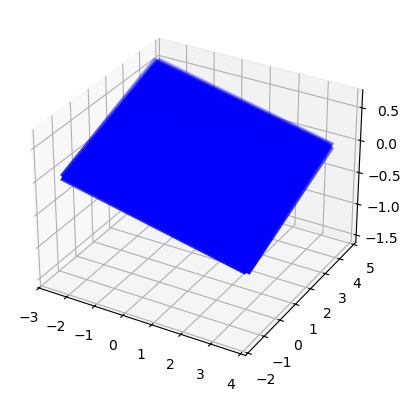

In [9]:
# plot atoms and grid points in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
atom_pos = sample.pos.cpu().detach().numpy()
ax.scatter(atom_pos[:, 0], atom_pos[:, 1], atom_pos[:, 2], c='r', marker='o', label='Atoms')
ax.scatter(grid_points[:, 0], grid_points[:, 1], grid_points[:, 2], c='b', marker='x', label='Grid Points')

# print minimum distance between atoms and grid points
min_dist = np.min(np.linalg.norm(atom_pos[:, None, :] - grid_points[None, :, :], axis=-1), axis=1)
print("Minimum distance between atoms and grid points:", min_dist)

rot_pos = (rot_mat.T @ (sample.pos.detach().cpu().numpy() - center).T).T
rot_pos_xy = rot_pos[:, :2]

In [ ]:
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable


def plot_2d(x, y, func, rot_pos_xy, scatter_kwargs, ax, label, atom_text, cbar=True, lims=None):
    if lims is None:
        lims = [np.min(func), np.max(func)]
    cf = ax.contourf(x, y, func.reshape(grid_size, grid_size), levels=100, vmin=lims[0], vmax=lims[1], cmap="viridis")
    cf.set_edgecolor("face")  
    # cbar that represents the whole color scale given by lims
    if cbar:
        # make cbar exaclty the same size as the plot
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=lims[0], vmax=lims[1])), cax=cax, fraction=0.1, pad=0.05)
    ax.scatter(rot_pos_xy[:, 0], rot_pos_xy[:, 1], **scatter_kwargs)
    # add text label to each atom
    for i, atom in enumerate(rot_pos_xy):
        ax.text(atom[0] + 0.1, atom[1] + 0.1, atom_text[i], fontsize=12, color="white")
    # add text label to the top left corner of the plot
    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', color="white") #bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    # remove ticks
    #make plot square
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

/tmp/ipykernel_303498/1371963413.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


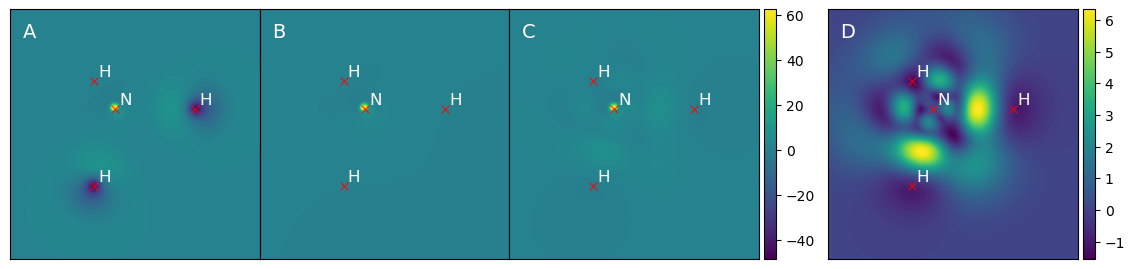

In [11]:
from matplotlib import gridspec
from mldft.utils.molecules import numbers_to_element_symbols

scatter_kwargs = {
    "s": 30,
    "alpha": 0.7,
    "color": "red",
    "linewidth": 1.0,
    "marker": "x",
}
atom_text = [numbers_to_element_symbols[atomic_number] for atomic_number in sample.atomic_numbers.cpu().detach().numpy()]

coeff_ind_to_node_ind = sample.coeff_ind_to_node_ind.cpu().detach().numpy()

# calculate feature functions on the grid
features = inputs[0].cpu().detach().numpy()
funcs = ao[0] @ features
# ind = 0
# contour plot of the first feature function
coeff_ind_to_node_ind = sample.coeff_ind_to_node_ind.cpu().detach().numpy()
# calculate feature functions on the grid
features = inputs[0].cpu().detach().numpy()
s_funcs = ao[0, :, coeff_ind_to_node_ind == 0].T @ features[coeff_ind_to_node_ind == 0]

output_feature = outputs_a[0].cpu().detach().numpy()
funcs_out = ao[0, :, coeff_ind_to_node_ind == 0].T @ output_feature[0]
# ind = 0
# contour plot of the first feature function

for ind in range(1):
    lims = (min(np.min(funcs[..., ind]), np.min(s_funcs[..., ind]), np.min(funcs_out[..., ind])),
            max(np.max(funcs[..., ind]), np.max(s_funcs[..., ind]), np.max(funcs_out[..., ind])))

    # Create a figure
    fig = plt.figure(figsize=(14, 4))

    # Create a GridSpec with 1 row and 2 columns for two groups of subplots
    gs_outer = gridspec.GridSpec(1, 2, width_ratios=[3.07, 1.07], wspace=0.1)  # Non-zero spacing between groups

    # First group: 3 subplots with zero spacing
    gs_first_three = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_outer[0], wspace=0.00, width_ratios=[1, 1, 1.07])
    
    # Second group: 1 subplot
    gs_last = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs_outer[1])

    # Create axes
    ax = [
        fig.add_subplot(gs_first_three[0]),
        fig.add_subplot(gs_first_three[1]),
        fig.add_subplot(gs_first_three[2]),
        fig.add_subplot(gs_last[0])
    ]

    # Plotting
    plot_2d(x, y, funcs[..., ind], rot_pos_xy, scatter_kwargs, ax[0], "A", atom_text, cbar=False, lims=lims)
    plot_2d(x, y, s_funcs[..., ind], rot_pos_xy, scatter_kwargs, ax[1], "B", atom_text, cbar=False, lims=lims)
    plot_2d(x, y, funcs_out[..., ind], rot_pos_xy, scatter_kwargs, ax[2], "C", atom_text, cbar=True, lims=lims)

    # Plot diff
    plot_2d(x, y, funcs_out[..., ind] - s_funcs[..., ind], rot_pos_xy, scatter_kwargs, ax[3], "D", atom_text, cbar=True)

    plt.tight_layout()
    plt.savefig("/export/home/mklockow/sciai-dft/data/figures/feature_functions.pdf", dpi=300)
    plt.show()